### Step 1: Import libraries

We import `requests` to call the ClinicalTrials.gov API and `json` to save the retrieved data.

In [2]:
import requests
import json

### Step 2: Set the API endpoint + Build Query

The endpoint `https://clinicaltrials.gov/api/v2/studies` allows access to study information using a programmatic query.



We want:
- Phase II or Phase III trials
- Status: Terminated
- Start date between Jan 1, 2015 and Jan 1, 2025

We use parentheses in the query to ensure the OR condition works correctly. This avoids empty results due to logical grouping issues.

In [3]:
url = "https://clinicaltrials.gov/api/v2/studies"

query = "(AREA[Phase]PHASE2 OR AREA[Phase]PHASE3) AND AREA[StartDate]RANGE[2015-01-01,2025-01-01]"
status_filter = "TERMINATED"
page_size = 100

### Step 3: Pagination loop

Since the API only returns a maximum number of results per page (100), we implement a loop with `nextPageToken` to collect all studies.
We also print the size of each batch for debugging.

In [4]:
all_studies = []
next_page_token = None

while True:
    params = {
        "query.term": query,
        "filter.overallStatus": status_filter,
        "pageSize": page_size
    }

    if next_page_token:
        params["pageToken"] = next_page_token

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print("Error:", response.status_code)
        print(response.text)
        break

    data = response.json()
    studies = data.get("studies", [])
    
    all_studies.extend(studies)
    print("Batch retrieved:", len(studies))

    next_page_token = data.get("nextPageToken")
    if not next_page_token:
        break

print("Total studies retrieved:", len(all_studies))

Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retrieved: 100
Batch retriev

### Step 4: Save raw JSON

We save the full dataset to `raw_clinical_trials.json` with indentation for readability.  
This preserves the original API response and allows reproducibility without re-querying.

In [5]:
with open("raw_clinical_trials.json", "w") as f:
    json.dump(all_studies, f, indent=2)

print("Raw data saved successfully.")
print("Number of studies saved:", len(all_studies))

Raw data saved successfully.
Number of studies saved: 5596


### Step 5: Verify raw data

Quick check to ensure the data structure is correct.

In [6]:
try:
    print("Type:", type(all_studies))
    print("Number of studies:", len(all_studies))
    print("Keys of first study:", all_studies[0].keys())
except NameError:
    print("all_studies does not exist. Run the API + pagination cell first.")
except IndexError:
    print("all_studies is empty. Check your query/pagination.")

Type: <class 'list'>
Number of studies: 5596
Keys of first study: dict_keys(['protocolSection', 'resultsSection', 'documentSection', 'derivedSection', 'hasResults'])


# Part 2 — Data Cleaning and Categorization

In this section, we:
1. Load the raw JSON data saved in Part 1.
2. Extract relevant fields for analysis:
   - NCT ID
   - Phase
   - `whyStopped`
3. Categorize termination reasons into six groups:
   - Efficacy
   - Safety
   - Operational
   - Strategy/Business
   - Enrollment
   - Unknown
4. Save a tidy CSV ready for analysis and figure generation.

In [18]:
# Import necessary libraries
import pandas as pd
import json

### Step 1 — Load raw data

We load the JSON file `raw_clinical_trials.json` obtained from the ClinicalTrials.gov API in Part 1.  
This step ensures reproducibility without querying the API again.

In [19]:
# Load raw data
with open("raw_clinical_trials.json", "r") as f:
    raw_data = json.load(f)

print("Total studies loaded:", len(raw_data))

Total studies loaded: 5596


### Step 2 — Inspect raw data structure

We check the first few studies to understand the JSON structure.  
This helps identify the correct keys to extract NCT ID, Phase, and termination reason (`whyStopped`).

In [20]:
# Inspect first 5 studies
for study in raw_data[:5]:
    protocol = study.get("protocolSection", {})
    status_module = protocol.get("statusModule", {})
    why_stopped = status_module.get("whyStopped", "")
    nct_id = protocol.get("identificationModule", {}).get("nctId", "")
    print(nct_id, "|", why_stopped[:50])  # first 50 characters

NCT03387046 | Study was terminated early due to slow recruitment
NCT04449588 | Due to the COVID-19 epidemic situation, the sponso
NCT03254927 | Sponsor decision based on emerging risk-benefit pr
NCT02769169 | study protocol changed
NCT03333083 | The reason for the premature termination was the f


### Step 3 — Extract relevant fields

We extract the following fields from each study:

- `nct_id` — Clinical trial identifier
- `phase` — Trial phase (Phase 2 or Phase 3)
- `why_stopped` — Reason the trial was terminated

This data will be stored in a pandas DataFrame for further analysis.

In [30]:
# Prepare list for DataFrame
cleaned_data = []

for study in raw_data:
    protocol = study.get("protocolSection", {})
    identification = protocol.get("identificationModule", {})
    status_module = protocol.get("statusModule", {})
    design_module = protocol.get("designModule", {})
    status_info = protocol.get("statusModule", {})

    nct_id = identification.get("nctId", "")
    why_stopped = status_module.get("whyStopped", "")

    # ✅ Phase extraction
    phase_list = design_module.get("phases", [])
    phase = ", ".join(phase_list) if phase_list else ""

    # ✅ NEW: Extract start date
    start_date = status_info.get("startDateStruct", {}).get("date", "")

    cleaned_data.append({
        "nct_id": nct_id,
        "phase": phase,
        "why_stopped": why_stopped,
        "start_date": start_date   # ⭐ THIS FIXES EVERYTHING
    })

# Create DataFrame
df = pd.DataFrame(cleaned_data)

print(df.head())
print(df['phase'].value_counts())

        nct_id           phase  \
0  NCT03387046          PHASE2   
1  NCT04449588  PHASE2, PHASE3   
2  NCT03254927          PHASE2   
3  NCT02769169  PHASE2, PHASE3   
4  NCT03333083          PHASE3   

                                         why_stopped  start_date  
0  Study was terminated early due to slow recruit...  2018-03-26  
1  Due to the COVID-19 epidemic situation, the sp...  2020-07-23  
2  Sponsor decision based on emerging risk-benefi...  2018-03-27  
3                             study protocol changed  2018-08-01  
4  The reason for the premature termination was t...  2018-05-03  
PHASE2            3033
PHASE3            1286
PHASE1, PHASE2     985
PHASE2, PHASE3     292
Name: phase, dtype: int64


In [31]:
print(df.columns)

Index(['nct_id', 'phase', 'why_stopped', 'start_date'], dtype='object')


### Step 4 — Categorize termination reasons

We define a function to map textual `whyStopped` entries into one of six categories:

1. Efficacy
2. Safety
3. Operational
4. Strategy/Business
5. Enrollment
6. Unknown

This standardizes the dataset for further analysis and plotting.

In [32]:
# Function to categorize termination reasons
def categorize_reason(text):
    if not text or text.strip() == "":
        return "unknown"
    text_lower = text.lower()
    if "efficacy" in text_lower or "did not work" in text_lower or "lack of effect" in text_lower:
        return "efficacy"
    elif "safety" in text_lower or "harm" in text_lower or "adverse" in text_lower:
        return "safety"
    elif "enroll" in text_lower or "recruit" in text_lower or "patient" in text_lower:
        return "enrollment"
    elif "logistic" in text_lower or "operation" in text_lower or "protocol" in text_lower:
        return "operational"
    elif "business" in text_lower or "strategy" in text_lower or "company decision" in text_lower or "sponsor decision" in text_lower:
        return "strategy/business"
    else:
        return "unknown"

# Apply categorization
df["category"] = df["why_stopped"].apply(categorize_reason)

# View category counts
print(df["category"].value_counts())

unknown              2597
enrollment           1394
strategy/business     622
safety                494
efficacy              403
operational            86
Name: category, dtype: int64


### Step 5 — Clean phase categories

We standardize trial phases into two groups:
- Phase II (includes Phase I/II)
- Phase III (includes Phase II/III)

This ensures consistency for analysis and matches the methodology used in the reference study.

In [33]:
# Create cleaned phase column
df['phase_clean'] = df['phase']

# Map phases
df.loc[df['phase'].str.contains("PHASE2") & ~df['phase'].str.contains("PHASE3"), 'phase_clean'] = "PHASE2"
df.loc[df['phase'].str.contains("PHASE3"), 'phase_clean'] = "PHASE3"

# Check results
print(df['phase_clean'].value_counts())

PHASE2    4018
PHASE3    1578
Name: phase_clean, dtype: int64


### Step 6 — Verify and save tidy dataset

We verify the structure of the cleaned dataset and ensure all required variables are present.

The dataset is then saved as tidy_clinical_trials.csv for use in Part 3.

Final columns include:
- nct_id
- phase
- phase_clean
- why_stopped
- category

In [34]:
# Verify final dataset
print(df.head())
print(df.info())

# Save tidy CSV (FINAL SAVE)
df.to_csv("tidy_clinical_trials.csv", index=False)

print("Tidy CSV saved successfully.")

        nct_id           phase  \
0  NCT03387046          PHASE2   
1  NCT04449588  PHASE2, PHASE3   
2  NCT03254927          PHASE2   
3  NCT02769169  PHASE2, PHASE3   
4  NCT03333083          PHASE3   

                                         why_stopped  start_date  \
0  Study was terminated early due to slow recruit...  2018-03-26   
1  Due to the COVID-19 epidemic situation, the sp...  2020-07-23   
2  Sponsor decision based on emerging risk-benefi...  2018-03-27   
3                             study protocol changed  2018-08-01   
4  The reason for the premature termination was t...  2018-05-03   

            category phase_clean  
0         enrollment      PHASE2  
1            unknown      PHASE3  
2  strategy/business      PHASE2  
3        operational      PHASE3  
4            unknown      PHASE3  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5596 entries, 0 to 5595
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       -----------

In [62]:
import os

# Create a folder to store outputs
os.makedirs("data", exist_ok=True)

# Save tidy CSV
df.to_csv("data/tidy_clinical_trials.csv", index=False, encoding='utf-8')
print("Tidy CSV saved at data/tidy_clinical_trials.csv")

Tidy CSV saved at data/tidy_clinical_trials.csv


## Part 3 - Figure Generation 

### Step 1 - Load Tidy Dataset
In this step, we load the cleaned and categorized dataset (`tidy_clinical_trials.csv`) from Part 2.  
This ensures reproducibility without re-querying the API. Columns include:

- `nct_id`  
- `phase`  
- `phase_clean`  
- `why_stopped`  
- `category`

In [35]:
import pandas as pd

# Load cleaned CSV from Part 2
df = pd.read_csv("tidy_clinical_trials.csv")

print("Total rows loaded:", len(df))
print(df.head())

Total rows loaded: 5596
        nct_id           phase  \
0  NCT03387046          PHASE2   
1  NCT04449588  PHASE2, PHASE3   
2  NCT03254927          PHASE2   
3  NCT02769169  PHASE2, PHASE3   
4  NCT03333083          PHASE3   

                                         why_stopped  start_date  \
0  Study was terminated early due to slow recruit...  2018-03-26   
1  Due to the COVID-19 epidemic situation, the sp...  2020-07-23   
2  Sponsor decision based on emerging risk-benefi...  2018-03-27   
3                             study protocol changed  2018-08-01   
4  The reason for the premature termination was t...  2018-05-03   

            category phase_clean  
0         enrollment      PHASE2  
1            unknown      PHASE3  
2  strategy/business      PHASE2  
3        operational      PHASE3  
4            unknown      PHASE3  


## Step 2 — Filter data by start year and relevant phases

We focus only on Phase II and Phase III trials (using `phase_clean`) to match the study scope.

In [36]:
# Filter only Phase II and Phase III trials
df_filtered = df[df['phase_clean'].isin(['PHASE2', 'PHASE3'])]

print("Filtered trials (Phase II & III):", len(df_filtered))
print(df_filtered['phase_clean'].value_counts())

Filtered trials (Phase II & III): 5596
PHASE2    4018
PHASE3    1578
Name: phase_clean, dtype: int64


### Step 3 - Count termintations by category and year
Here we count the number of terminations by reason (category).  
If a `start_year` column exists, we can also group by year for trend analysis (2015-2025).

In [37]:
# Check if start_year exists
if 'start_year' in df_filtered.columns:
    grouped = df_filtered.groupby(['start_year', 'category']).size().unstack(fill_value=0)
else:
    grouped = df_filtered.groupby('category').size()
    
print(grouped)

category
efficacy              403
enrollment           1394
operational            86
safety                494
strategy/business     622
unknown              2597
dtype: int64


### Figure 3 — Clinical Trial Terminations by Year (2015–2025)

This figure shows the number of Phase II and Phase III clinical trials terminated each year, grouped by the reason for termination. The numbers on top of each bar indicate the total trials terminated for that category in a given year.

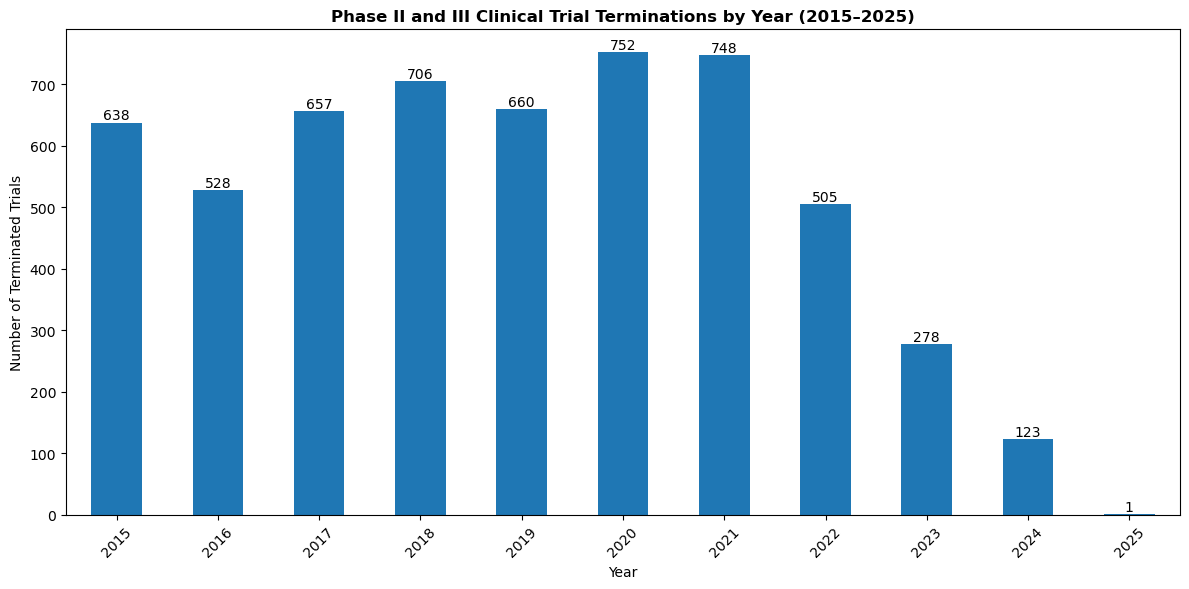

In [67]:
import matplotlib.pyplot as plt

# Convert start_date → year
df_filtered['start_date'] = pd.to_datetime(df_filtered['start_date'], errors='coerce')
df_filtered['start_year'] = df_filtered['start_date'].dt.year

# Filter years
df_plot = df_filtered[(df_filtered['start_year'] >= 2015) & (df_filtered['start_year'] <= 2025)]

# ✅ Total terminations per year (NO category breakdown)
year_counts = df_plot.groupby('start_year').size()

# Plot
fig, ax = plt.subplots(figsize=(12,6))

year_counts.plot(kind='bar', ax=ax)

# Add values on top of bars
for i, value in enumerate(year_counts):
    ax.text(i, value + 5, str(int(value)), ha='center', fontsize=10)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Terminated Trials")
ax.set_title("Phase II and III Clinical Trial Terminations by Year (2015–2025)", fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig.savefig("Figure_1a.png", dpi=300, bbox_inches='tight')

### Figure 4 — Proportion of Clinical Trial Terminations by Reason (2015–2025)

This figure shows the percentage distribution of termination reasons for Phase II and Phase III clinical trials. Each segment represents the proportion of trials terminated for a given reason.

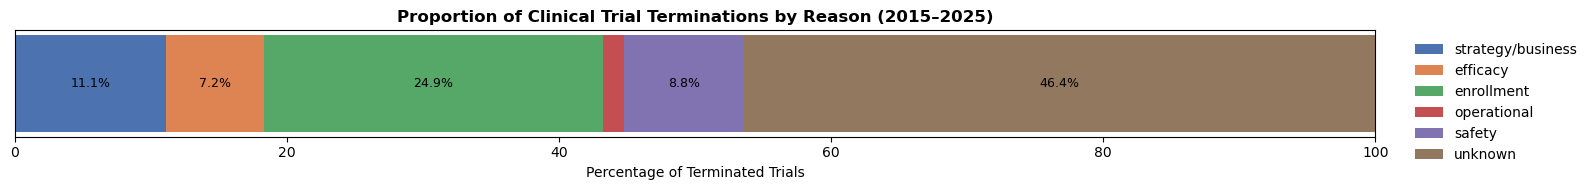

In [68]:
import matplotlib.pyplot as plt

# Color mapping
color_map = {
    "strategy/business": "#4C72B0",
    "efficacy": "#DD8452",
    "enrollment": "#55A868",
    "operational": "#C44E52",
    "safety": "#8172B2",
    "unknown": "#937860"
}

# Ensure consistent order (important for legend + visual)
category_order = [
    "strategy/business",
    "efficacy",
    "enrollment",
    "operational",
    "safety",
    "unknown"
]

category_percent = category_percent.reindex(category_order)

# Plot
fig, ax = plt.subplots(figsize=(16, 2))

left = 0
for category, value in category_percent.items():
    ax.barh(
        0,
        value,
        left=left,
        height=0.35,
        color=color_map.get(category, "grey"),
        label=category
    )
    
    if value > 3:  # avoid clutter for tiny segments
        ax.text(left + value/2, 0, f"{value:.1f}%", ha='center', va='center', fontsize=9)
    
    left += value

# Formatting
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Percentage of Terminated Trials")

ax.set_title(
    "Proportion of Clinical Trial Terminations by Reason (2015–2025)",
    fontweight='bold'
)

# Clean legend
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

fig.savefig("Figure_1b.png", dpi=300, bbox_inches='tight')

### Figure 2 — Trends in Clinical Trial Terminations by Phase (2015–2025)

(a) Phase II trials  
(b) Phase III trials  
(c) Trends in termination reasons over time (excluding unknown)

In [44]:
# Convert date
df_filtered['start_date'] = pd.to_datetime(df_filtered['start_date'], errors='coerce')
df_filtered['start_year'] = df_filtered['start_date'].dt.year

# Filter years
df_plot = df_filtered[(df_filtered['start_year'] >= 2015) & (df_filtered['start_year'] <= 2025)]

# Function to compute % per year
def compute_percent(df_phase):
    counts = df_phase.groupby(['start_year', 'category']).size().unstack(fill_value=0)
    totals = df_phase.groupby('start_year').size()
    percent = counts.div(totals, axis=0) * 100
    return percent

# Split
df_phase2 = df_plot[df_plot['phase_clean'] == 'PHASE2']
df_phase3 = df_plot[df_plot['phase_clean'] == 'PHASE3']

percent_phase2 = compute_percent(df_phase2)
percent_phase3 = compute_percent(df_phase3)

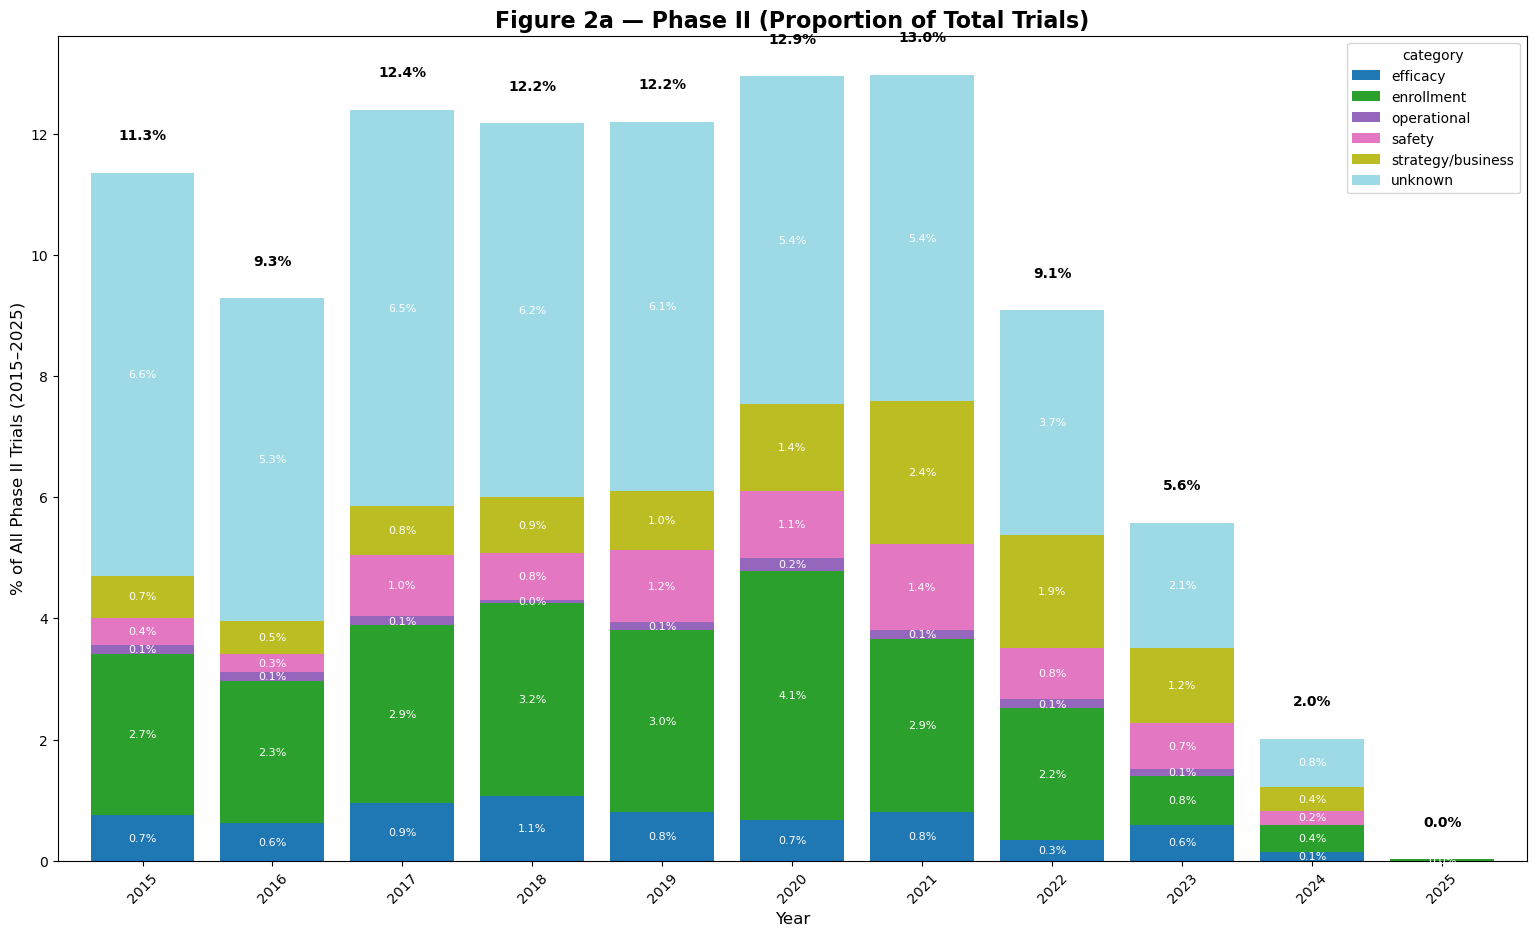

In [64]:
import matplotlib.pyplot as plt

# Filter Phase II
df_phase2 = df_filtered[df_filtered['phase_clean'] == "PHASE2"]

# Total trials across all years
total_phase2 = len(df_phase2)

# Count by year + category
counts_phase2 = df_phase2.groupby(['start_year', 'category']).size().unstack(fill_value=0)

# Convert to % of total
percent_phase2 = (counts_phase2 / total_phase2) * 100

# Plot with taller figure
fig, ax = plt.subplots(figsize=(16,10))  # taller figure

percent_phase2.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    cmap='tab20',
    width=0.8
)

# Add percentage labels inside each segment
for i, year in enumerate(percent_phase2.index):
    bottom = 0
    for category in percent_phase2.columns:
        pct = percent_phase2.loc[year, category]
        if pct > 0:
            ax.text(
                i, 
                bottom + pct/2, 
                f"{pct:.1f}%", 
                ha='center', 
                va='center', 
                fontsize=8,
                color='white'
            )
            bottom += pct
    # Add total percentage label just above the bar
    ax.text(
        i, 
        bottom + 0.5,  # same small offset as before
        f"{bottom:.1f}%", 
        ha='center', 
        va='bottom', 
        fontsize=10,
        fontweight='bold'
    )

ax.set_title("Figure 2a — Phase II (Proportion of Total Trials)", fontweight='bold', fontsize=16)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of All Phase II Trials (2015–2025)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout(pad=3)
plt.show()

# Save figure
fig.savefig("Figure_2a_PhaseII.png", dpi=300, bbox_inches='tight')

### Figure 2b — Phase III (Proportion of Total Trials)

This figure shows the proportion of all Phase III trials from 2015–2025, broken down by termination reason.  
Each bar represents the percentage of Phase III trials for that year relative to the **total number of Phase III trials** (all years).  

- Each segment shows the percentage of trials terminated for that category.
- The total percentage for each year is labeled above the bar.

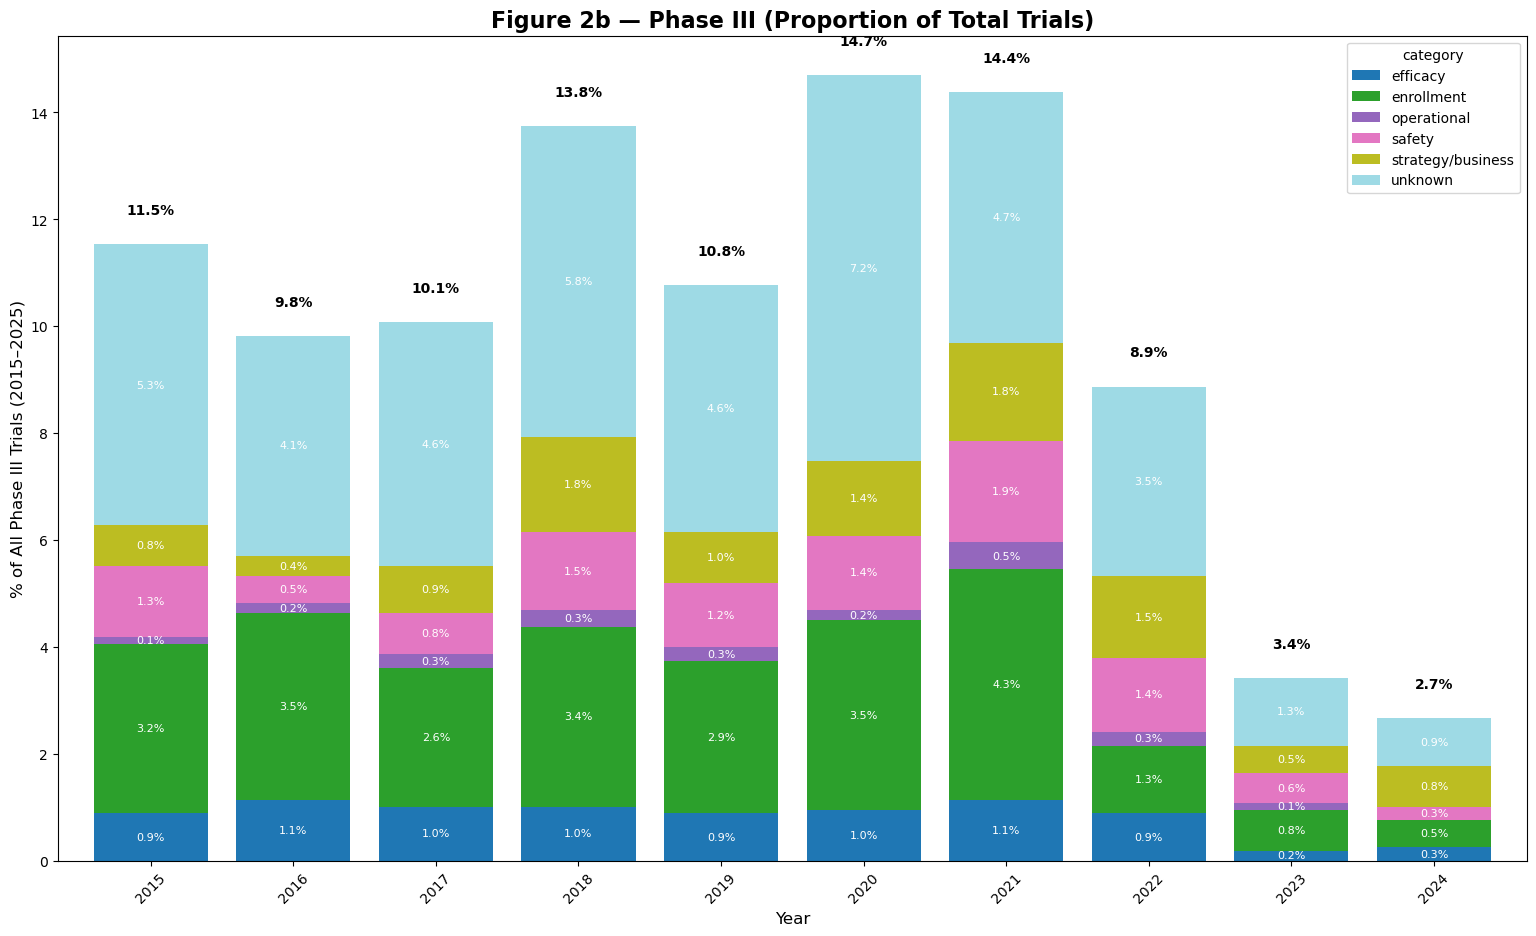

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter Phase III
df_phase3 = df_filtered[df_filtered['phase_clean'] == "PHASE3"]

# Create start_year if not exists
if 'start_year' not in df_phase3.columns:
    if 'start_date' in df_phase3.columns:
        df_phase3['start_date'] = pd.to_datetime(df_phase3['start_date'], errors='coerce')
        df_phase3['start_year'] = df_phase3['start_date'].dt.year
    else:
        raise ValueError("No start_date column found — cannot create start_year")

# Total trials across all Phase III
total_phase3 = len(df_phase3)

# Count by year + category
counts_phase3 = df_phase3.groupby(['start_year', 'category']).size().unstack(fill_value=0)

# Convert to % of total Phase III trials
percent_phase3 = (counts_phase3 / total_phase3) * 100

# Plot
fig, ax = plt.subplots(figsize=(16,10))  # taller figure

percent_phase3.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    cmap='tab20',
    width=0.8
)

# Add percentage labels inside segments and total above bar
for i, year in enumerate(percent_phase3.index):
    bottom = 0
    for category in percent_phase3.columns:
        pct = percent_phase3.loc[year, category]
        if pct > 0:
            ax.text(
                i,
                bottom + pct/2,
                f"{pct:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                color='white'
            )
            bottom += pct
    ax.text(
        i,
        bottom + 0.5,
        f"{bottom:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title("Figure 2b — Phase III (Proportion of Total Trials)", fontweight='bold', fontsize=16)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of All Phase III Trials (2015–2025)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout(pad=3)
plt.show()

fig.savefig("Figure_2b_PhaseIII.png", dpi=300, bbox_inches='tight')

### Figure 2c — Line Graph of Termination Reasons

This figure shows the yearly trend of each termination reason (excluding 'unknown') for Phase II and Phase III trials.  

- Each graph represents one reason (efficacy, safety, enrollment, operational, strategy/business).
- The y-axis shows the **percentage of total trials** for that year.

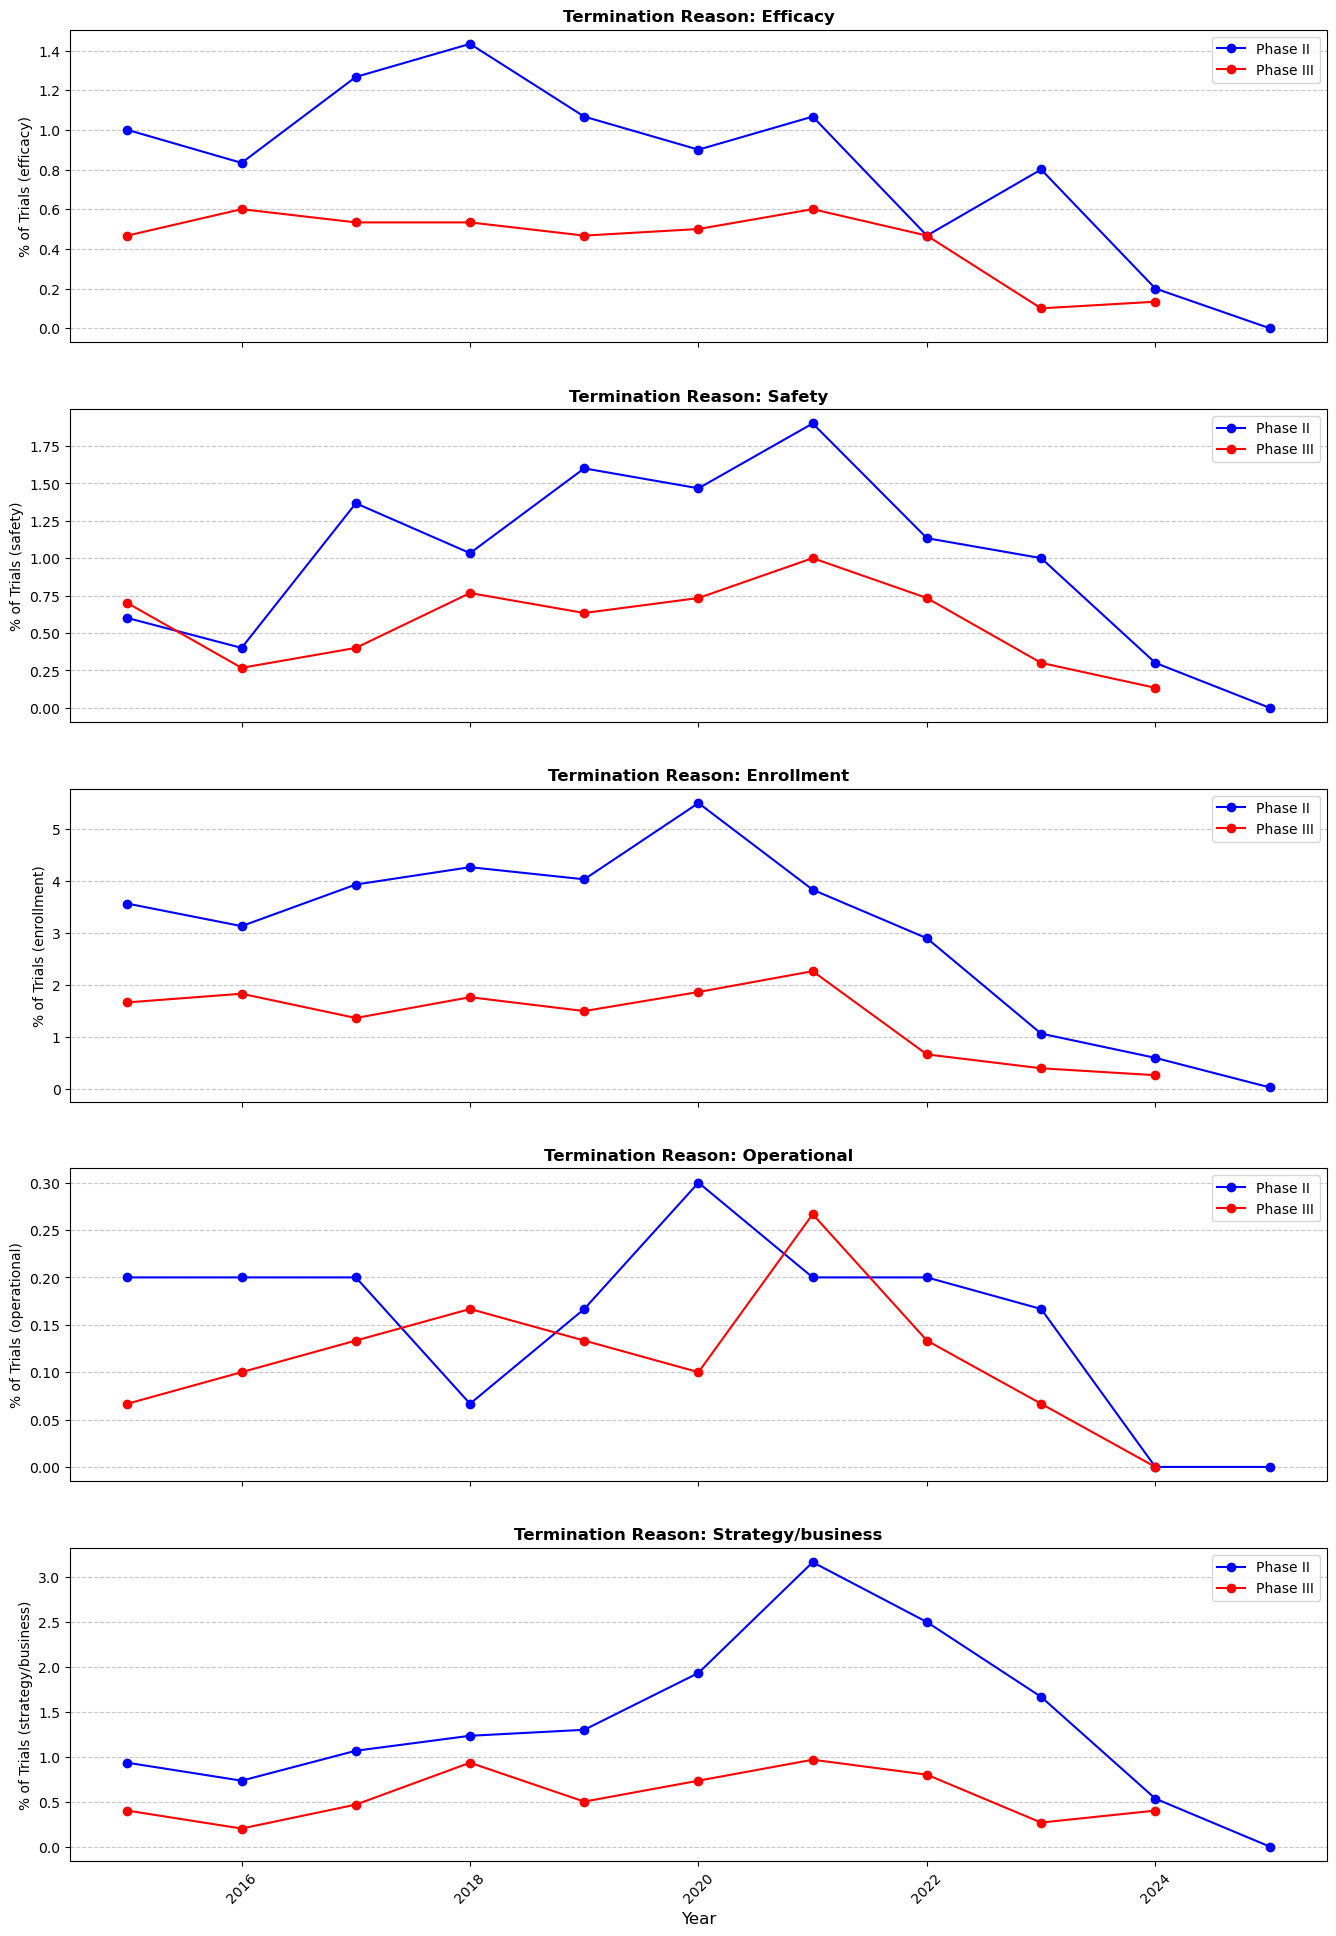

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

# Define reasons to plot
reasons = ["efficacy", "safety", "enrollment", "operational", "strategy/business"]

# Filter out 'unknown'
df_known = df_filtered[df_filtered['category'].isin(reasons)]

# Ensure start_year exists
if 'start_year' not in df_known.columns:
    if 'start_date' in df_known.columns:
        df_known['start_date'] = pd.to_datetime(df_known['start_date'], errors='coerce')
        df_known['start_year'] = df_known['start_date'].dt.year
    else:
        raise ValueError("No start_date column found — cannot create start_year")

# Separate Phase II and Phase III
df_phase2 = df_known[df_known['phase_clean'] == "PHASE2"]
df_phase3 = df_known[df_known['phase_clean'] == "PHASE3"]

# Compute yearly percentages of total trials (all years)
total_trials = len(df_known)  # all trials included for percentage calculation

percent2 = df_phase2.groupby(['start_year', 'category']).size().div(total_trials) * 100
percent3 = df_phase3.groupby(['start_year', 'category']).size().div(total_trials) * 100

# Unstack to get years as index, categories as columns
percent2 = percent2.unstack(fill_value=0)
percent3 = percent3.unstack(fill_value=0)

# Create subplots (5 rows, 1 column)
fig, axes = plt.subplots(len(reasons), 1, figsize=(14, 20), sharex=True)

for i, reason in enumerate(reasons):
    ax = axes[i]
    # Plot Phase II
    if reason in percent2.columns:
        ax.plot(percent2.index, percent2[reason], color='blue', marker='o', label='Phase II')
    # Plot Phase III
    if reason in percent3.columns:
        ax.plot(percent3.index, percent3[reason], color='red', marker='o', label='Phase III')
    
    ax.set_ylabel(f"% of Trials ({reason})", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    ax.set_title(f"Termination Reason: {reason.capitalize()}", fontsize=12, fontweight='bold')

axes[-1].set_xlabel("Year", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout(pad=3)
plt.show()

fig.savefig("Figure_2c_Trend_LineGraph.png", dpi=300, bbox_inches='tight')

In [63]:
import os
print(os.getcwd())

C:\Users\Owner


In [69]:
import pandas as pd

# Load the tidy dataset
df = pd.read_csv("tidy_clinical_trials.csv")

# Ensure start_date is datetime and create start_year
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['start_year'] = df['start_date'].dt.year

# Filter for 2015-2025
df = df[(df['start_year'] >= 2015) & (df['start_year'] <= 2025)]

# --- 1. Total terminations by category (all trials) ---
total_by_category = df.groupby('category').size().rename("Total_All_Phases")
print("Total terminations by category (all trials):")
print(total_by_category)
print("\n")

# --- 2. Total terminations by category for Phase II ---
phase2 = df[df['phase_clean'] == 'PHASE2']
total_phase2 = phase2.groupby('category').size().rename("Total_Phase2")
print("Phase II terminations by category:")
print(total_phase2)
print("\n")

# --- 3. Total terminations by category for Phase III ---
phase3 = df[df['phase_clean'] == 'PHASE3']
total_phase3 = phase3.groupby('category').size().rename("Total_Phase3")
print("Phase III terminations by category:")
print(total_phase3)
print("\n")

# --- 4. Yearly breakdown by category (all trials) ---
yearly_category = df.groupby(['start_year', 'category']).size().unstack(fill_value=0)
print("Yearly breakdown of terminations by category:")
print(yearly_category)
print("\n")

# --- 5. Yearly breakdown by category for Phase II ---
yearly_phase2 = phase2.groupby(['start_year', 'category']).size().unstack(fill_value=0)
print("Phase II: yearly breakdown by category:")
print(yearly_phase2)
print("\n")

# --- 6. Yearly breakdown by category for Phase III ---
yearly_phase3 = phase3.groupby(['start_year', 'category']).size().unstack(fill_value=0)
print("Phase III: yearly breakdown by category:")
print(yearly_phase3)
print("\n")

# Optional: Save summary to CSV
summary_folder = "data"
import os
os.makedirs(summary_folder, exist_ok=True)

with pd.ExcelWriter(f"{summary_folder}/clinical_trials_summary.xlsx") as writer:
    total_by_category.to_frame().to_excel(writer, sheet_name="Total_All")
    total_phase2.to_frame().to_excel(writer, sheet_name="Total_Phase2")
    total_phase3.to_frame().to_excel(writer, sheet_name="Total_Phase3")
    yearly_category.to_excel(writer, sheet_name="Yearly_All")
    yearly_phase2.to_excel(writer, sheet_name="Yearly_Phase2")
    yearly_phase3.to_excel(writer, sheet_name="Yearly_Phase3")

print(f"Summary tables saved to {summary_folder}/clinical_trials_summary.xlsx")

Total terminations by category (all trials):
category
efficacy              375
enrollment           1214
operational            81
safety                472
strategy/business     591
unknown              2281
Name: Total_All_Phases, dtype: int64


Phase II terminations by category:
category
efficacy              255
enrollment            862
operational            47
safety                311
strategy/business     426
unknown              1705
Name: Total_Phase2, dtype: int64


Phase III terminations by category:
category
efficacy             120
enrollment           352
operational           34
safety               161
strategy/business    165
unknown              576
Name: Total_Phase3, dtype: int64


Yearly breakdown of terminations by category:
category    efficacy  enrollment  operational  safety  strategy/business  \
start_year                                                                 
2015.0            30          57            6      23                 20   
2016.0      

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table
import os

# Make sure your summary tables exist
# total_by_category, total_phase2, total_phase3, yearly_category, yearly_phase2, yearly_phase3

# Create output folder
os.makedirs("data", exist_ok=True)
pdf_folder = "data"
pdf_file = os.path.join(pdf_folder, "clinical_trials_summary_report.pdf")

# List of tables and titles
tables = [
    ("Total Trials by Category (All Phases)", total_by_category.to_frame()),
    ("Total Trials by Category (Phase II)", total_phase2.to_frame()),
    ("Total Trials by Category (Phase III)", total_phase3.to_frame()),
    ("Yearly Trials by Category (All Phases)", yearly_category),
    ("Yearly Trials by Category (Phase II)", yearly_phase2),
    ("Yearly Trials by Category (Phase III)", yearly_phase3),
]

# Loop through tables and save each as a page in the PDF
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(pdf_file) as pdf:
    for title, df_table in tables:
        fig, ax = plt.subplots(figsize=(12, max(2, len(df_table)/2)))  # height adjusts to table size
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
        tbl = table(ax, df_table, loc='center', cellLoc='center')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1, 1.5)
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"PDF report generated successfully: {pdf_file}")

PDF report generated successfully: data\clinical_trials_summary_report.pdf
